In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

In [ ]:
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def find_uploaded_image(keyword, fallback_index):
    matches = [
        name for name in uploaded_names
        if keyword.lower() in name.lower()
    ]

    if matches:
        return '/content/' + matches[0]

    if fallback_index < len(uploaded_names):
        return '/content/' + uploaded_names[fallback_index]
    raise FileNotFoundError(f'Image Not Found: {keyword}')

opencv_inv_path = find_uploaded_image('opencv_inv', 0)
opening_path = find_uploaded_image('opening', 1)
closing_path = find_uploaded_image('closing', 2)

print('Input Images Loaded:')
print(opencv_inv_path)
print(opening_path)
print(closing_path)

Saving closing.png to closing.png
Saving opencv_inv.png to opencv_inv.png
Saving Opening.png to Opening.png
Input Images Loaded:
/content/opencv_inv.png
/content/Opening.png
/content/closing.png


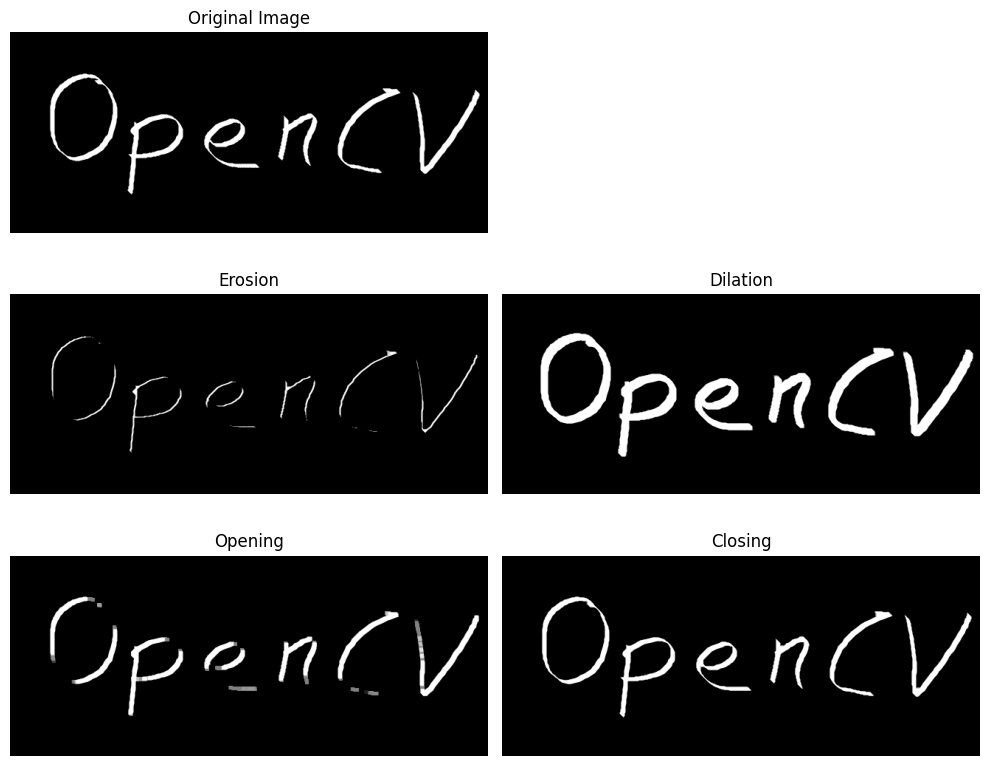

In [ ]:
image = cv2.imread(opencv_inv_path, cv2.IMREAD_GRAYSCALE)
if image is None:
  raise ValueError('The Main Input Image Could Not Be Loaded')

square_kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(image, square_kernel, iterations=1)
dilation = cv2.dilate(image, square_kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, square_kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, square_kernel)

plt.figure(figsize=(10, 8))

plt.subplot(3, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.tight_layout()
plt.show()

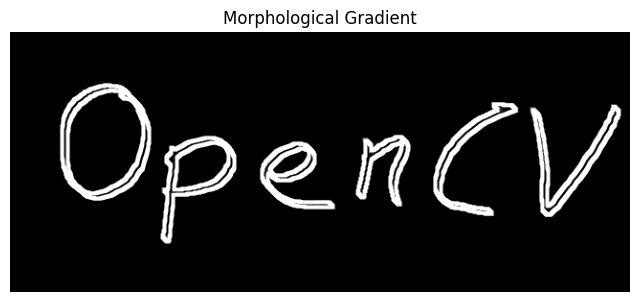

In [ ]:
morphological_gradient = cv2.subtract(dilation, erosion)

plt.figure(figsize=(8, 5))

plt.imshow(morphological_gradient, cmap='gray')
plt.title('Morphological Gradient')
plt.axis('off')

plt.show()

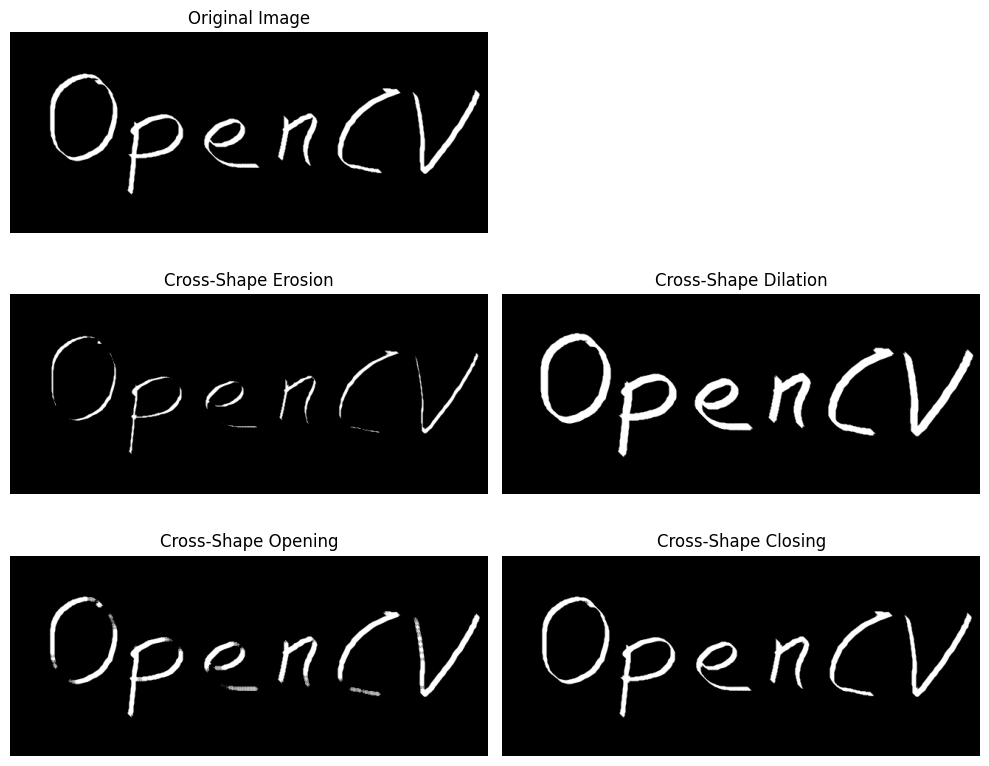

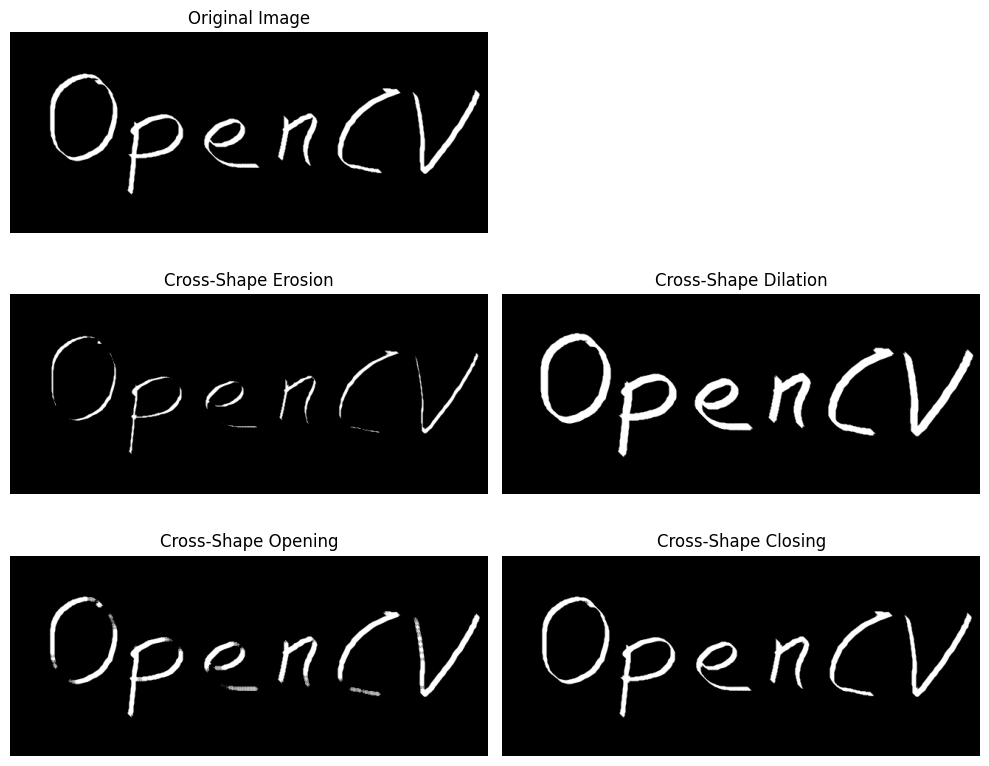

In [ ]:
cross_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5), (2, 2))

cross_erosion = cv2.erode(image, cross_kernel, iterations=1)
cross_dilation = cv2.dilate(image, cross_kernel, iterations=1)
cross_opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, cross_kernel)
cross_closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, cross_kernel)

plt.figure(figsize=(10, 8))

plt.subplot(3, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(cross_erosion, cmap='gray')
plt.title('Cross-Shape Erosion')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(cross_dilation, cmap='gray')
plt.title('Cross-Shape Dilation')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(cross_opening, cmap='gray')
plt.title('Cross-Shape Opening')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(cross_closing, cmap='gray')
plt.title('Cross-Shape Closing')
plt.axis('off')

plt.tight_layout()
plt.show()

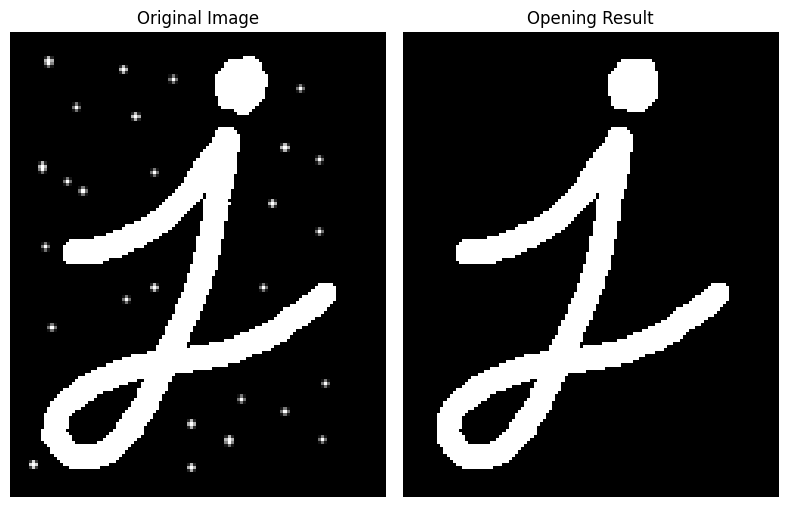

In [ ]:
opening_image = cv2.imread(opening_path, cv2.IMREAD_GRAYSCALE)
if opening_image is None:
  raise ValueError('The Opening Input Image Could Not Be Loaded')

opening_result = cv2.morphologyEx(opening_image, cv2.MORPH_OPEN, square_kernel)

plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.imshow(opening_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(opening_result, cmap='gray')
plt.title('Opening Result')
plt.axis('off')

plt.tight_layout()
plt.show()

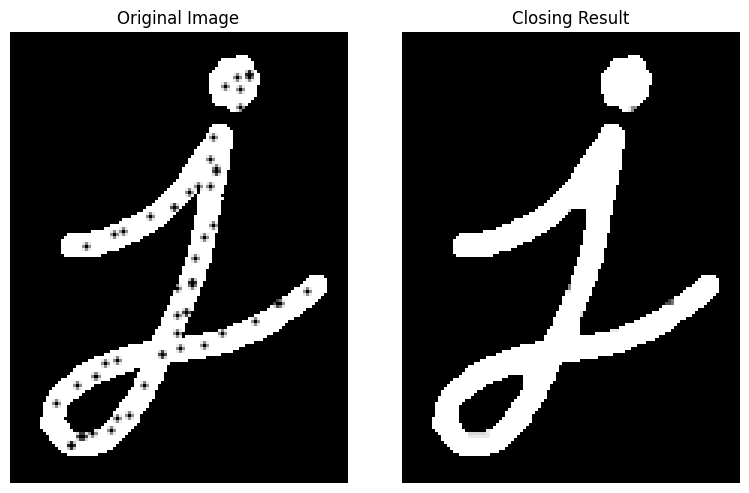

In [14]:
closing_image = cv2.imread(closing_path, cv2.IMREAD_GRAYSCALE)
if closing_image is None:
  raise ValueError('The Closing Input Image Could Not Be Loaded')

closing_result = cv2.morphologyEx(closing_image, cv2.MORPH_CLOSE, square_kernel)

plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.imshow(closing_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(closing_result, cmap='gray')
plt.title('Closing Result')
plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
output_images = {
    'erosion.png': erosion,
    'dilation.png': dilation,
    'opening.png': opening,
    'closing.png': closing,
    'morphological_gradient.png': morphological_gradient,
    'cross_erosion.png': cross_erosion,
    'cross_dilation.png': cross_dilation,
    'cross_opening.png': cross_opening,
    'cross_closing.png': cross_closing,
}

for filename, image in output_images.items():
    output_path = '/content/' + filename
    cv2.imwrite(output_path, image)
    files.download(filename)
    print('Saved:', filename)
    print('Downloaded:', filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: erosion.png
Downloaded: erosion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Saved: cross_opening.png
Downloaded: cross_opening.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: cross_closing.png
Downloaded: cross_closing.png
